In [1]:
!pip install sentence-transformers seaborn matplotlib

In [2]:
from sentence_transformers import SentenceTransformer, util
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch

# 1. 10 sentences across 3 topics (Cricket, Cooking, Cybersecurity)
sentences = [
    "Virat Kohli scored a magnificent century in the world cup final.", # Cricket
    "The test match ended in an exciting draw after five days.", # Cricket
    "Fast bowlers rely on swing and pace to dismiss the batsmen.", # Cricket
    "Slow cooking the meat at a low temperature makes it very tender.", # Cooking
    "Always season your pasta water with plenty of salt before boiling.", # Cooking
    "A pinch of turmeric and cumin adds great flavor to Indian curries.", # Cooking
    "Baking bread at home requires patience and the right amount of yeast.", # Cooking
    "Multi-factor authentication is essential for securing your online accounts.", # Cybersecurity
    "Phishing attacks often use fake emails to steal sensitive user data.", # Cybersecurity
    "Firewalls act as a barrier between a trusted network and the internet." # Cybersecurity
]

# 2. Load the model
model = SentenceTransformer('all-MiniLM-L6-v2')

# 3. Generate embeddings
embeddings = model.encode(sentences, convert_to_tensor=True)
print("Embeddings generated successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embeddings generated successfully!


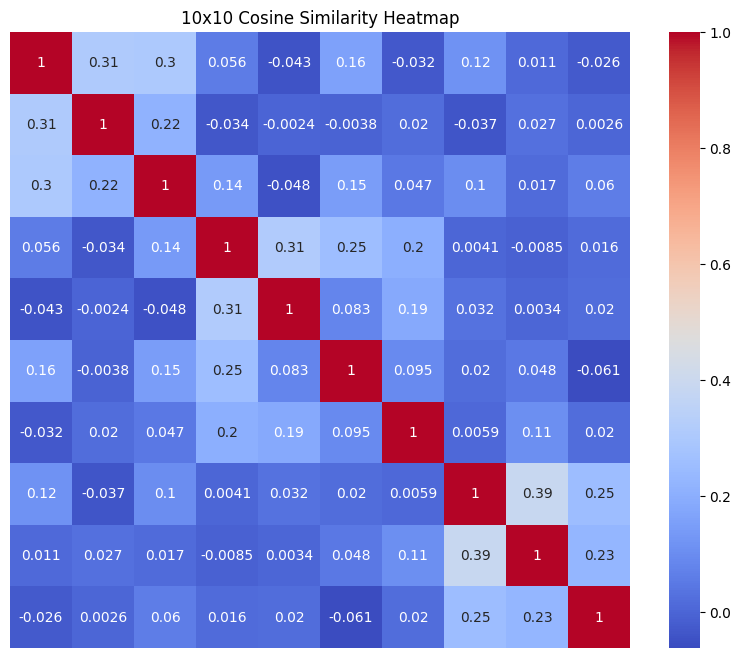

In [3]:
# Compute cosine similarity matrix
cosine_scores = util.cos_sim(embeddings, embeddings)

# Convert to numpy for plotting
matrix = cosine_scores.cpu().numpy()

# 4. Display Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, cmap='coolwarm', xticklabels=False, yticklabels=False)
plt.title("10x10 Cosine Similarity Heatmap")
plt.show()

In [4]:
# 5. Query Sentence
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query, convert_to_tensor=True)

# Find similarities
search_scores = util.cos_sim(query_embedding, embeddings)[0]

# Get top 2 results
top_results = torch.topk(search_scores, k=2)

print(f"Query: {query}\n")
print("Top 2 Most Similar Sentences:")
for score, idx in zip(top_results[0], top_results[1]):
    print(f"- {sentences[idx]} (Score: {score:.4f})")

Query: The bowler took three wickets in one over

Top 2 Most Similar Sentences:
- Fast bowlers rely on swing and pace to dismiss the batsmen. (Score: 0.4834)
- Virat Kohli scored a magnificent century in the world cup final. (Score: 0.3912)
